# A notebook to train a RANDOM FOREST to perfom a PIXEL-based classification of kontas_2017 dataset

## Import Usepackages

In [1]:
import torch
import gc

# Force clear everything
torch.cuda.empty_cache()
gc.collect()


import numpy as np
import seaborn as sns
import random
import cv2
import mlflow
import joblib

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from matplotlib.colors import ListedColormap

from pathlib import Path
from PIL import Image

import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, jaccard_score
from sklearn.inspection import permutation_importance
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

from mpl_toolkits.axes_grid1 import make_axes_locatable


## Pre-defined Functions

In [2]:
# Hand-Crafted Feature Engineering
# Extract 16 features from RGB-based images.

def extract_features(image):
    """
    Extract hand-crafted features for each pixel.
    Returns: (height, width, n_features)
    """

    # Convert tensor to numpy if needed
    if torch.is_tensor(image):
        image = image.cpu().numpy()
        # If tensor is (C, H, W), convert to (H, W, C)
        if image.ndim == 3 and image.shape[0] in [1, 3]:
            image = np.transpose(image, (1, 2, 0))
        # If normalized to [0, 1], scale to [0, 255]
        if image.max() <= 1.0:
            image = (image * 255).astype(np.uint8)
    
    h, w = image.shape[:2]
    features = []
    
    # Ensure image is uint8 for OpenCV operations
    if image.dtype != np.uint8:
        image = np.clip(image, 0, 255).astype(np.uint8)
    
    # Convert to float for calculations
    img_float = image.astype(np.float32)
    
    # 1. RGB values (3 features)
    features.append(image[:, :, 0])  # R
    features.append(image[:, :, 1])  # G
    features.append(image[:, :, 2])  # B
    
    # 2. Color ratios (3 features)
    features.append(image[:, :, 0] / (image[:, :, 2] + 1e-6))  # R/B ratio
    features.append(image[:, :, 1] / (image[:, :, 2] + 1e-6))  # G/B ratio
    features.append((image[:, :, 0] - image[:, :, 2]) / (image[:, :, 0] + image[:, :, 2] + 1e-6))  # Normalized R-B
    
    # 3. HSV color space (3 features)
    hsv = cv2.cvtColor(img_float, cv2.COLOR_RGB2HSV)
    features.append(hsv[:, :, 0])  # Hue
    features.append(hsv[:, :, 1])  # Saturation
    features.append(hsv[:, :, 2])  # Value
    
    # 4. Local texture features (4 features)
    gray = cv2.cvtColor(img_float, cv2.COLOR_RGB2GRAY)
    # Ensure gray is uint8
    if gray.dtype != np.uint8:
        gray = np.clip(gray, 0, 255).astype(np.uint8)
    features.append(cv2.GaussianBlur(gray, (5, 5), 0))  # Smoothed intensity
    #features.append(cv2.Laplacian(gray, cv2.CV_64F))  # Edge detection
    laplacian = cv2.Laplacian(gray, cv2.CV_64F)
    features.append(laplacian.astype(np.float32))  # Edge detection
    features.append(cv2.Sobel(gray, cv2.CV_64F, 1, 0, ksize=3))  # Gradient X
    features.append(cv2.Sobel(gray, cv2.CV_64F, 0, 1, ksize=3))  # Gradient Y
    
    # 5. Local statistics (3 features)
    kernel_size = 7
    mean_filter = cv2.blur(gray.astype(float), (kernel_size, kernel_size))
    features.append(mean_filter)  # Local mean
    
    variance = cv2.blur((gray.astype(float) - mean_filter)**2, (kernel_size, kernel_size))
    features.append(variance)  # Local variance
    features.append(np.sqrt(variance + 1e-6))  # Local std
    
    # Stack all features: (height, width, n_features)
    feature_stack = np.stack(features, axis=-1)
    
    return feature_stack

In [3]:
def predict_image(image, rf_model):
    """Predict segmentation mask for a single image using Random Forest."""
    
    # Ensure correct shape
    img = np.array(image).squeeze()  # (512, 512, 3)
    
    # Extract features
    features = extract_features(img)              # (512, 512, n_features)
    h, w     = img.shape[:2]
    
    # Flatten for RF
    X        = features.reshape(-1, features.shape[-1])  # (n_pixels, n_features)
    
    # Predict
    pred     = rf_model.predict(X)                # (n_pixels,)
    mask     = pred.reshape(h, w)                 # (512, 512)
    
    return mask

def predict_image_pca(image, rf_model, scaler, pca):
    img      = np.array(image).squeeze()
    features = extract_features(img)                        # (512, 512, n_features)
    h, w     = img.shape[:2]
    X        = features.reshape(-1, features.shape[-1])     # (n_pixels, n_features)
    X_scaled = scaler.transform(X)                          # scale
    X_pca    = pca_final.transform(X_scaled)                # reduce
    pred     = rf_model.predict(X_pca)                      # predict
    return pred.reshape(h, w)


In [4]:
def show_predicted_images(idxExample,imgExample,masks,pred_mask,pred_mask_pca):

    cmap = ListedColormap(['black', 'blue', 'white'])

    fig, axes = plt.subplots(2, 4, figsize=(15, 5))

    axes[0,0].imshow(imgExample.squeeze())
    axes[0,0].set_title(f'Original Image {idxExample}')
    axes[0,0].axis('off')

    axes[0,1].imshow(masks[idxExample:idxExample+1].squeeze(), cmap=cmap, vmin=0, vmax=2)
    axes[0,1].set_title(f'Original Mask')
    axes[0,1].axis('off')

    axes[0,2].imshow(pred_mask.squeeze(), cmap=cmap, vmin=0, vmax=2)
    axes[0,2].set_title(f'Predicted Mask')
    axes[0,2].axis('off')


    axes[0,3].imshow(pred_mask_pca.squeeze(), cmap=cmap, vmin=0, vmax=2)
    axes[0,3].set_title(f'Predicted Mask (PCA)')
    axes[0,3].axis('off')

    diff = masks[idxExample].squeeze().astype(int) - pred_mask.squeeze().astype(int)

    im  = axes[1,2].imshow(diff, cmap='RdBu', vmin=-2, vmax=2)
    axes[1,2].set_title('Mask Differences')
    axes[1,2].axis('off')


    diff_pca = masks[idxExample].squeeze().astype(int) - pred_mask_pca.squeeze().astype(int)

    im  = axes[1,3].imshow(diff_pca, cmap='RdBu', vmin=-2, vmax=2)
    axes[1,3].set_title('Mask Differences (PCA)')
    axes[1,3].axis('off')


    axes[1,0].axis('off')  # just turn it off — leaves it blank
    axes[1,1].axis('off')  # just turn it off — leaves it blank

    # Attach colorbar to axes[3] without stealing space from other plots
    divider = make_axes_locatable(axes[1,3])
    cax     = divider.append_axes("right", size="5%", pad=0.05)
    plt.colorbar(im, cax=cax, ticks=[-2, -1, 0, 1, 2])


    unique, counts = np.unique(diff, return_counts=True)
    total = diff.size

    print(f"{'Value':>8} {'Count':>10} {'Percentage':>12}")
    print("-" * 32)
    for val, cnt in zip(unique, counts):
        print(f"{val:>8} {cnt:>10,} {cnt/total:>11.1%}")

    unique_pca, counts_pca = np.unique(diff_pca, return_counts=True)
    total_pca = diff_pca.size

    print(f"{'Value':>8} {'Count':>10} {'Percentage':>12}")
    print("-" * 32)
    for val, cnt in zip(unique_pca, counts_pca):
        print(f"{val:>8} {cnt:>10,} {cnt/total_pca:>11.1%}")


# Load Data

The data were generated with the script: 01_kontas2017_dataPreparation. Therefore, they only have to be loaded here!

In [5]:
# Load in another notebook:
data   = np.load("dataset.npz") #np.savez("dataset.npz", images=images, masks=masks)
images = data["images"].copy()  # force full load
masks  = data["masks"].copy()
data.close()
del data

print("Number of images: ",len(images))
print("Number of masks: ",len(masks))
print(f" - Size of an image: {images[0].shape}")
print(" - Size of a mask: ",masks[0].shape)


Number of images:  1540
Number of masks:  1540
 - Size of an image: (512, 512, 3)
 - Size of a mask:  (512, 512)


## Feature Extraction

The function memmap from numpy is used to avoid problems with "Kernel crash".

In [6]:
sample_f   = extract_features(images[0])
n_features = sample_f.shape[-1]
n_pixels   = 512 * 512
n_images   = len(images)

# Write to disk instead of RAM — reads/writes like a normal numpy array
all_features = np.memmap("all_features.npy", dtype=np.float32, mode="w+",
                          shape=(n_images * n_pixels, n_features))
all_masks    = np.memmap("all_masks.npy",    dtype=np.uint8,   mode="w+",
                          shape=(n_images * n_pixels,))

for idx in range(n_images):
    start = idx * n_pixels
    end   = start + n_pixels

    f = extract_features(images[idx])
    all_features[start:end] = f.reshape(-1, n_features)
    all_masks[start:end]    = masks[idx].reshape(-1)

    if idx % 100 == 0:
        print(f"{idx}/{n_images} done")

# Flush to disk
all_features.flush()
all_masks.flush()
print("Done!")

0/1540 done
100/1540 done
200/1540 done
300/1540 done
400/1540 done
500/1540 done
600/1540 done
700/1540 done
800/1540 done
900/1540 done
1000/1540 done
1100/1540 done
1200/1540 done
1300/1540 done
1400/1540 done
1500/1540 done
Done!


## Data Size Reduction

In [7]:
# Number of pixels
print(all_features.shape)  # (n_images * n_pixels, n_features)
print(all_masks.shape)     # (n_images * n_pixels,)

(403701760, 16)
(403701760,)


In [8]:
n_samples = 150000
indices   = np.random.choice(len(all_features), size=n_samples, replace=False)


X_sample = all_features[indices]
y_sample = all_masks[indices]

print(f"X_sample: {X_sample.shape}")  
print(f"y_sample: {y_sample.shape}")

X_sample: (150000, 16)
y_sample: (150000,)


In [9]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_sample, y_sample, test_size=0.2, random_state=42, stratify=y_sample
)

print(f"\nTraining samples: {len(X_train):,}")
print(f"Class distribution: {np.bincount(y_train.astype(int))}")
print(f"Test samples: {len(X_test):,}")
print(f"Class distribution: {np.bincount(y_test.astype(int))}")


Training samples: 120,000
Class distribution: [26964 55054 37982]
Test samples: 30,000
Class distribution: [ 6741 13764  9495]


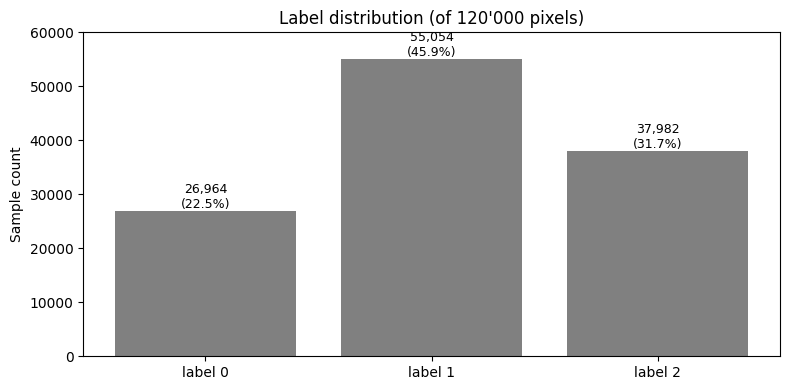

In [10]:
counts = np.bincount(y_train.astype(int))
classes = [f'label {i}' for i in range(len(counts))]

plt.figure(figsize=(8, 4))
plt.bar(classes, counts, color=['gray'])
plt.ylabel('Sample count')
plt.title('Label distribution (of 120\'000 pixels)')
for i, c in enumerate(counts):
    plt.text(i, c + counts.max()*0.01, f'{c:,}\n({c/counts.sum()*100:.1f}%)', ha='center', fontsize=9)
plt.tight_layout()
plt.ylim((0,60000))
plt.show()


## Optimize the Hyperparameters of the Random Forest

In [11]:
# Test different options for n_est, max_depth and maxFeature
# Fixing minSample = 20 and minSampleLeaf = 5

class_names = ['Class 0', 'Class 1', 'Class 2']
results = []

mlflow.set_experiment("allsky-rf")

    
maxFeature = ['sqrt', 'log2']

for n_est in [10, 50, 100, 200]:
    for max_depth in [5, 10, 20, 30, None]:
        #for minSample in [5, 10, 20, 30]:
        #    for minSampleLeaf in [5, 10, 20, 30]:
                for maxF in maxFeature:
                    minSample = 20
                    minSampleLeaf = 5 

                    with mlflow.start_run():
                        rf = RandomForestClassifier(
                            n_estimators=n_est,
                            max_depth=max_depth,
                            min_samples_split=minSample,
                            min_samples_leaf=minSampleLeaf,
                            max_features=maxF,
                            verbose=1,
                            n_jobs=-1, random_state=42,
                            class_weight='balanced'
                        )
                        rf.fit(X_train, y_train)
                        y_pred = rf.predict(X_test)

                        train_acc = rf.score(X_train, y_train)
                        test_acc  = rf.score(X_test,  y_test)
                        iou       = jaccard_score(y_test, y_pred, average=None)
                        mean_iou  = iou.mean()
                        report    = classification_report(y_test, y_pred, output_dict=True)
                        cm        = confusion_matrix(y_test, y_pred)

                        mlflow.log_params({"n_estimators": n_est, "max_depth": max_depth, "min_samples_split": minSample, "min_samples_leaf": minSampleLeaf, "max_features": maxF})
                        mlflow.log_metrics({
                            "train_accuracy": train_acc,
                            "test_accuracy":  test_acc,
                            "mean_iou":       mean_iou,
                            "macro_f1":       report["macro avg"]["f1-score"],
                        })

                        results.append({
                            "label":      f"{n_est},{max_depth},{maxF}",
                            "train_acc":  train_acc,
                            "test_acc":   test_acc,
                            "mean_iou":   mean_iou,
                            "macro_f1":   report["macro avg"]["f1-score"],
                            "iou":        iou,
                            "f1":         [report[str(i)]["f1-score"] for i in range(3)],
                            "precision":  [report[str(i)]["precision"] for i in range(3)],
                            "recall":     [report[str(i)]["recall"] for i in range(3)],
                            "cm":         cm,
                        })
                        print(f"n_est={n_est}, depth={max_depth}, maxFeature={maxF} -> acc={test_acc:.3f}, mIoU={mean_iou:.3f}")



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.2s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   2 out of  10 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   2 out of  10 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   2 out of  10 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:    0.0s finished


n_est=10, depth=5, maxFeature=sqrt -> acc=0.896, mIoU=0.836


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.1s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   2 out of  10 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   2 out of  10 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   2 out of  10 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:    0.0s finished


n_est=10, depth=5, maxFeature=log2 -> acc=0.896, mIoU=0.836


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  10 out of  10 | elapsed:    0.1s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   2 out of  10 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   2 out of  10 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=10)]: Using backend ThreadingBackend with 10 concurrent workers.
[Parallel(n_jobs=10)]: Done   2 out of  10 | elapsed:    0.0s remaining:    0.0s
[Parallel(n_jobs=10)]: Done  10 out of  10 | elapsed:    0.0s finished
[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


...

[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    2.2s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    2.7s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.2s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.2s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 200 out of 200 | 

n_est=200, depth=None, maxFeature=sqrt -> acc=0.917, mIoU=0.865


[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done 168 tasks      | elapsed:    2.4s
[Parallel(n_jobs=-1)]: Done 200 out of 200 | elapsed:    2.8s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.2s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s


n_est=200, depth=None, maxFeature=log2 -> acc=0.917, mIoU=0.865


[Parallel(n_jobs=16)]: Done 168 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done 200 out of 200 | elapsed:    0.1s finished


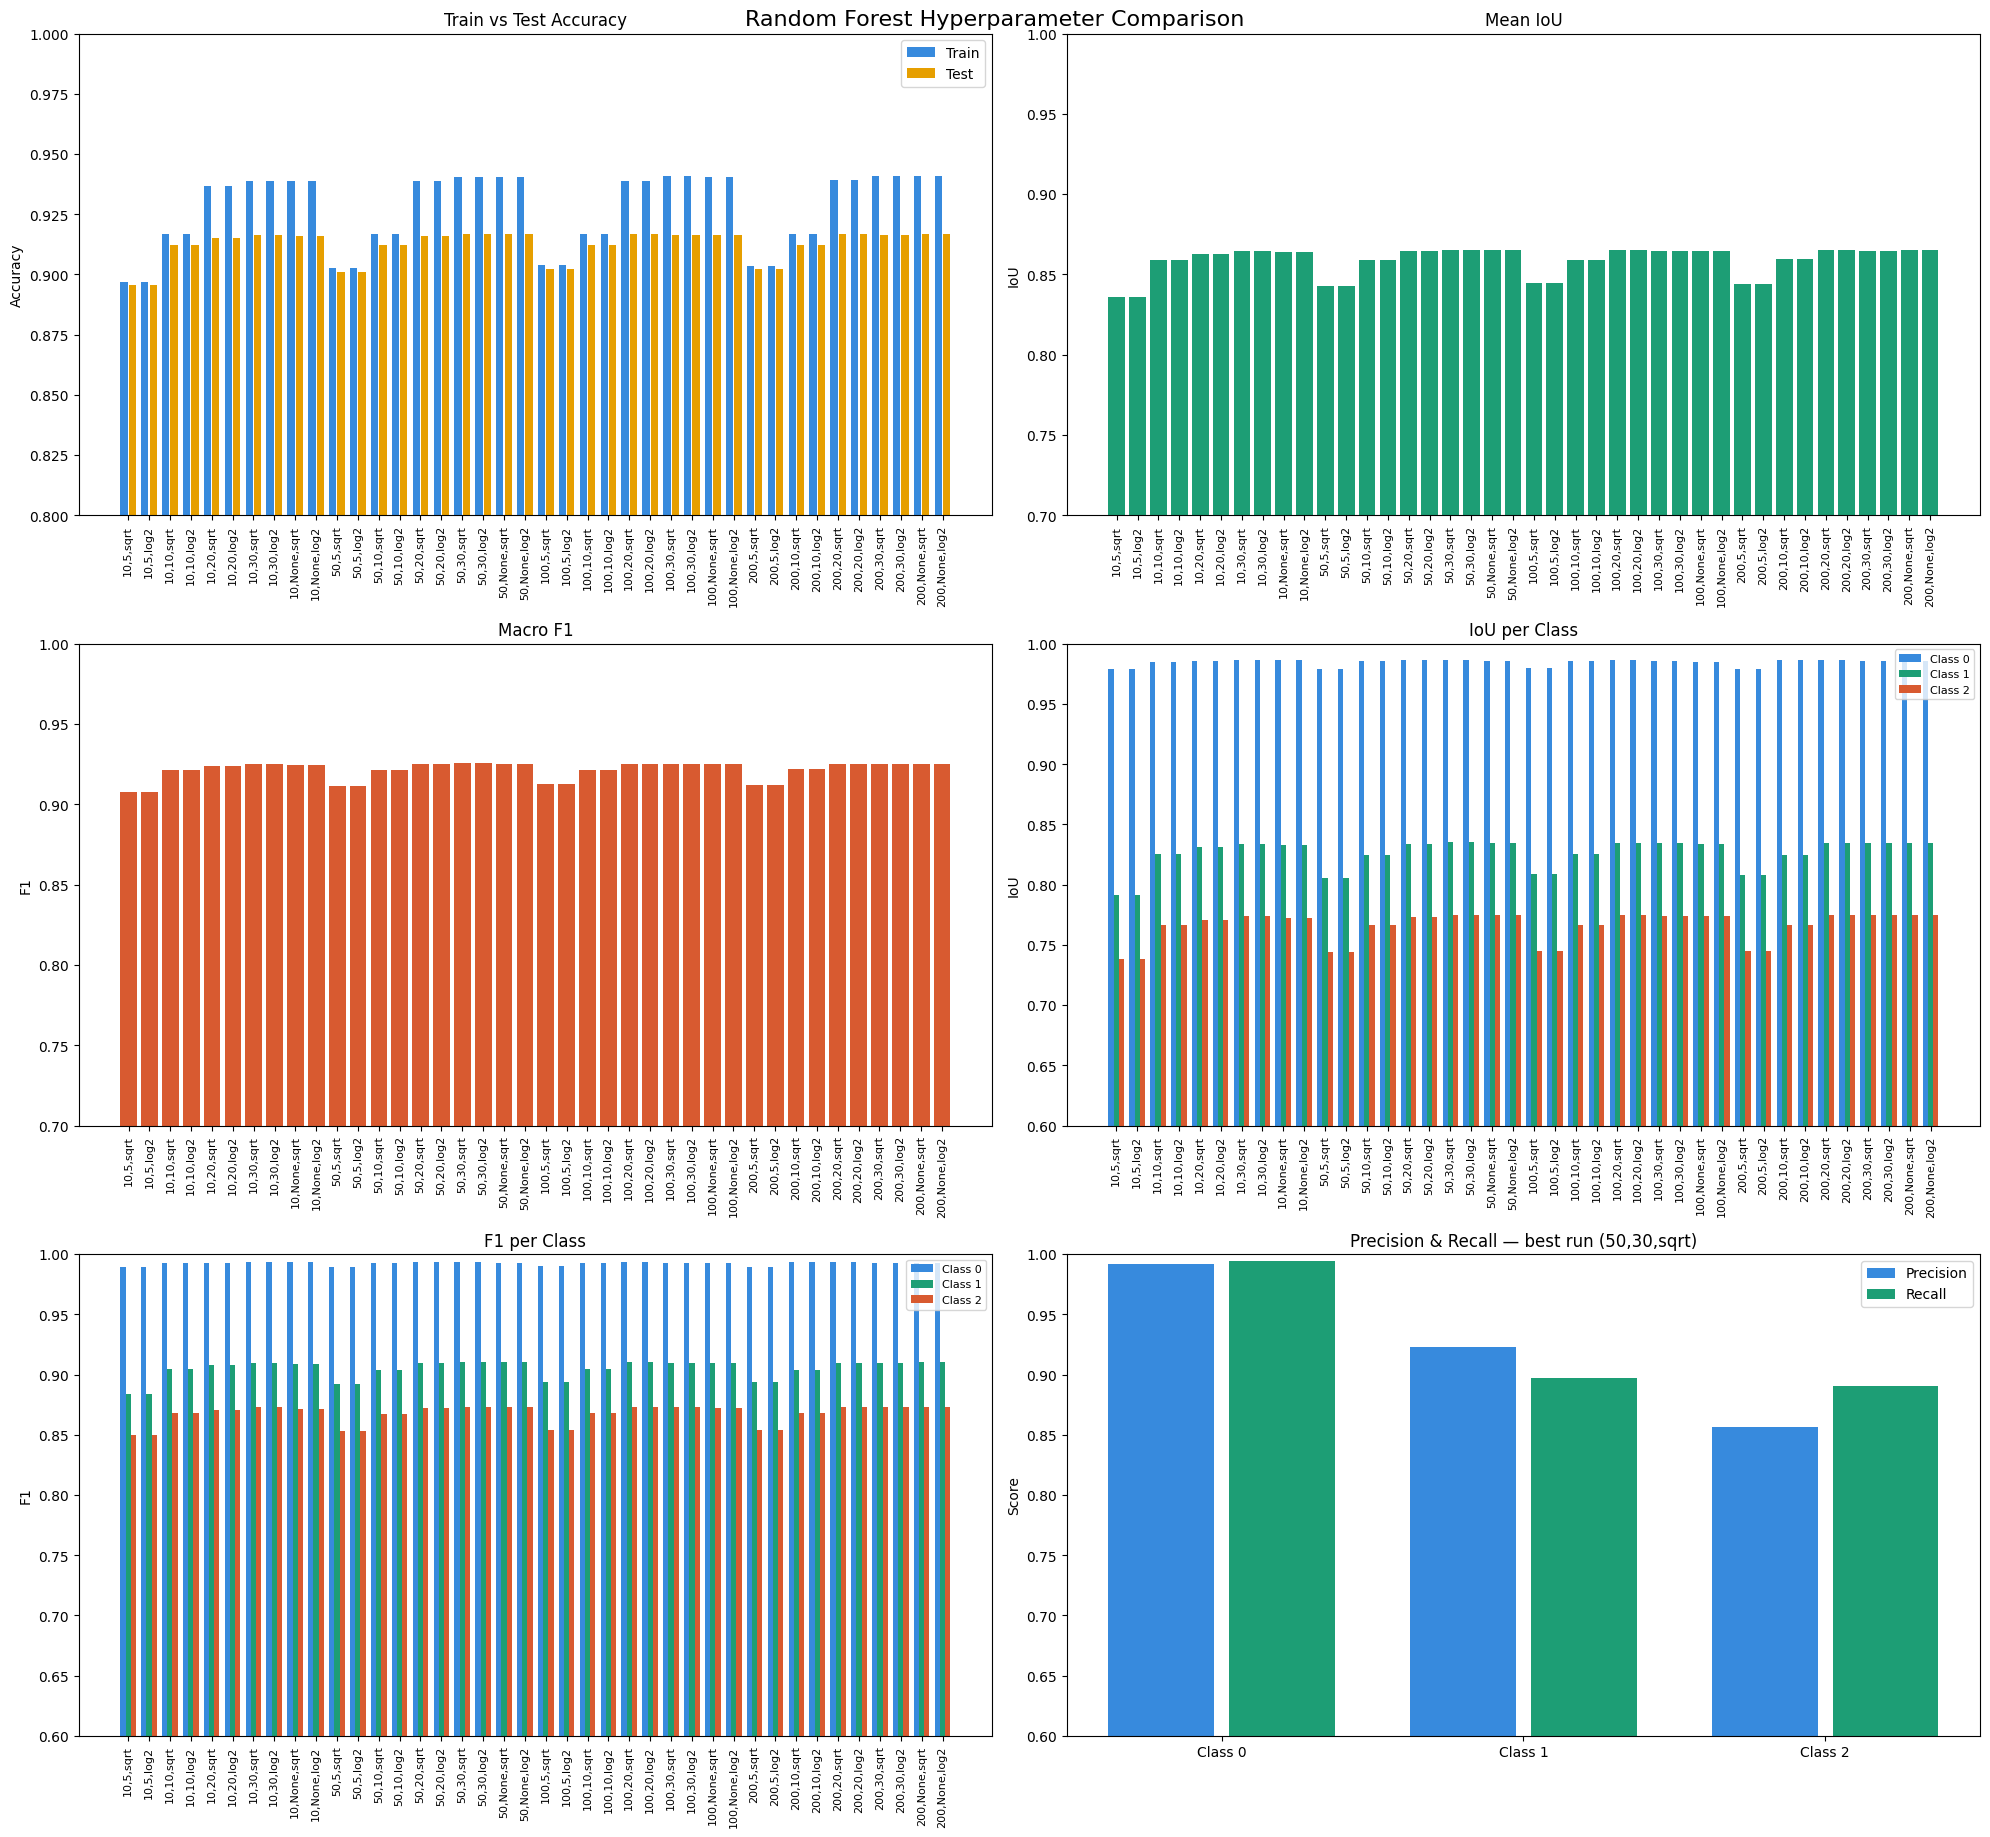


Best run: 50,30,sqrt -> test_acc=0.917


In [12]:
# ── Plots ─────────────────────────────────────────────────────────────
n_runs  = len(results)
labels  = [r["label"] for r in results]
x       = np.arange(n_runs)


fig = plt.figure(figsize=(20, 24))
fig.suptitle("Random Forest Hyperparameter Comparison", fontsize=16, y=0.98)
plt.subplots_adjust(bottom=-0.3, right=0.8, top=0.9)
# ── 1. Train vs test accuracy ─────────────────────────────────────────
ax1 = fig.add_subplot(4, 2, 1)
ax1.bar(x - 0.2, [r["train_acc"] for r in results], 0.35, label="Train", color="#378ADD")
ax1.bar(x + 0.2, [r["test_acc"]  for r in results], 0.35, label="Test",  color="#E69F00")
ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=8)
ax1.set_ylim(0.8, 1.0); ax1.set_title("Train vs Test Accuracy")
ax1.legend(); ax1.set_ylabel("Accuracy")
ax1.set_xticks(x, labels, rotation='vertical')

# ── 2. Mean IoU ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(4, 2, 2)
ax2.bar(x, [r["mean_iou"] for r in results], color="#1D9E75")
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=8)
ax2.set_ylim(0.7, 1.0); ax2.set_title("Mean IoU")
ax2.set_ylabel("IoU")
ax2.set_xticks(x, labels, rotation='vertical')

# ── 3. Macro F1 ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(4, 2, 3)
ax3.bar(x, [r["macro_f1"] for r in results], color="#D85A30")
ax3.set_xticks(x); ax3.set_xticklabels(labels, fontsize=8)
ax3.set_ylim(0.7, 1.0); ax3.set_title("Macro F1")
ax3.set_ylabel("F1")
ax3.set_xticks(x, labels, rotation='vertical')

# ── 4. IoU per class ─────────────────────────────────────────────────
ax4 = fig.add_subplot(4, 2, 4)
colors = ["#378ADD", "#1D9E75", "#D85A30"]
width  = 0.25
for i, cls in enumerate(class_names):
    ax4.bar(x + (i-1)*width, [r["iou"][i] for r in results], width,
            label=cls, color=colors[i])
ax4.set_xticks(x); ax4.set_xticklabels(labels, fontsize=8)
ax4.set_ylim(0.6, 1.0); ax4.set_title("IoU per Class")
ax4.legend(fontsize=8); ax4.set_ylabel("IoU")
ax4.set_xticks(x, labels, rotation='vertical')

# ── 5. F1 per class ──────────────────────────────────────────────────
ax5 = fig.add_subplot(4, 2, 5)
for i, cls in enumerate(class_names):
    ax5.bar(x + (i-1)*width, [r["f1"][i] for r in results], width,
            label=cls, color=colors[i])
ax5.set_xticks(x); ax5.set_xticklabels(labels, fontsize=8)
ax5.set_ylim(0.6, 1.0); ax5.set_title("F1 per Class")
ax5.legend(fontsize=8); ax5.set_ylabel("F1")
ax5.set_xticks(x, labels, rotation='vertical')

# ── 6. Precision & Recall per class (best run only) ──────────────────
best_idx = np.argmax([r["test_acc"] for r in results])
best1     = results[best_idx]
x3       = np.arange(3)
ax6      = fig.add_subplot(4, 2, 6)
ax6.bar(x3 - 0.2, best1["precision"], 0.35, label="Precision", color="#378ADD")
ax6.bar(x3 + 0.2, best1["recall"],    0.35, label="Recall",    color="#1D9E75")
ax6.set_xticks(x3); ax6.set_xticklabels(class_names)
ax6.set_ylim(0.6, 1.0); ax6.set_title(f"Precision & Recall — best run ({best1['label'].replace(chr(10), ', ')})")
ax6.legend(); ax6.set_ylabel("Score")


plt.tight_layout()
plt.savefig("rf_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nBest run: {results[best_idx]['label'].replace(chr(10), ', ')} -> test_acc={results[best_idx]['test_acc']:.3f}")

In [13]:
# Get the best options of run 1

label = best1['label']  # '200,30,sqrt'
parts = label.split(',')
n_est = int(parts[0])   # 200
max_depth    = int(parts[1])   # 30
maxF =  str(parts[2])       # 'sqrt' (keep as string)

In [14]:
# Test different options for minSample and minSampleLeaf
# Fixing minSample = 20 and minSampleLeaf = 5


class_names = ['Class 0', 'Class 1', 'Class 2']
results = []

mlflow.set_experiment("allsky-rf")

#maxFeature = ['sqrt']


for minSample in [5, 10, 20, 30]:
    for minSampleLeaf in [5, 10, 20, 30]:
                    with mlflow.start_run():
                        rf = RandomForestClassifier(
                            n_estimators=n_est,
                            max_depth=max_depth,
                            min_samples_split=minSample,
                            min_samples_leaf=minSampleLeaf,
                            max_features=maxF,
                            verbose=1,
                            n_jobs=-1, random_state=42,
                            class_weight='balanced'
                        )
                        rf.fit(X_train, y_train)
                        y_pred = rf.predict(X_test)

                        train_acc = rf.score(X_train, y_train)
                        test_acc  = rf.score(X_test,  y_test)
                        iou       = jaccard_score(y_test, y_pred, average=None)
                        mean_iou  = iou.mean()
                        report    = classification_report(y_test, y_pred, output_dict=True)
                        cm        = confusion_matrix(y_test, y_pred)

                        mlflow.log_params({"n_estimators": n_est, "max_depth": max_depth, "min_samples_split": minSample, "min_samples_leaf": minSampleLeaf, "max_features": maxF})
                        mlflow.log_metrics({
                            "train_accuracy": train_acc,
                            "test_accuracy":  test_acc,
                            "mean_iou":       mean_iou,
                            "macro_f1":       report["macro avg"]["f1-score"],
                        })

                        results.append({
                            "label":      f"{minSample},{minSampleLeaf}",
                            "train_acc":  train_acc,
                            "test_acc":   test_acc,
                            "mean_iou":   mean_iou,
                            "macro_f1":   report["macro avg"]["f1-score"],
                            "iou":        iou,
                            "f1":         [report[str(i)]["f1-score"] for i in range(3)],
                            "precision":  [report[str(i)]["precision"] for i in range(3)],
                            "recall":     [report[str(i)]["recall"] for i in range(3)],
                            "cm":         cm,
                        })
                        print(f"n_est={n_est}, depth={max_depth}, maxFeature={maxF}, minSamplesSplit={minSample}, minSampleLeaf={minSampleLeaf} -> acc={test_acc:.3f}, mIoU={mean_iou:.3f}")



[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    0.8s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


n_est=50, depth=30, maxFeature=sqrt, minSamplesSplit=5, minSampleLeaf=5 -> acc=0.915, mIoU=0.863


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    0.8s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


n_est=50, depth=30, maxFeature=sqrt, minSamplesSplit=5, minSampleLeaf=10 -> acc=0.915, mIoU=0.863


...

[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    0.7s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


n_est=50, depth=30, maxFeature=sqrt, minSamplesSplit=30, minSampleLeaf=20 -> acc=0.914, mIoU=0.861


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.3s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    0.7s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


n_est=50, depth=30, maxFeature=sqrt, minSamplesSplit=30, minSampleLeaf=30 -> acc=0.914, mIoU=0.862


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


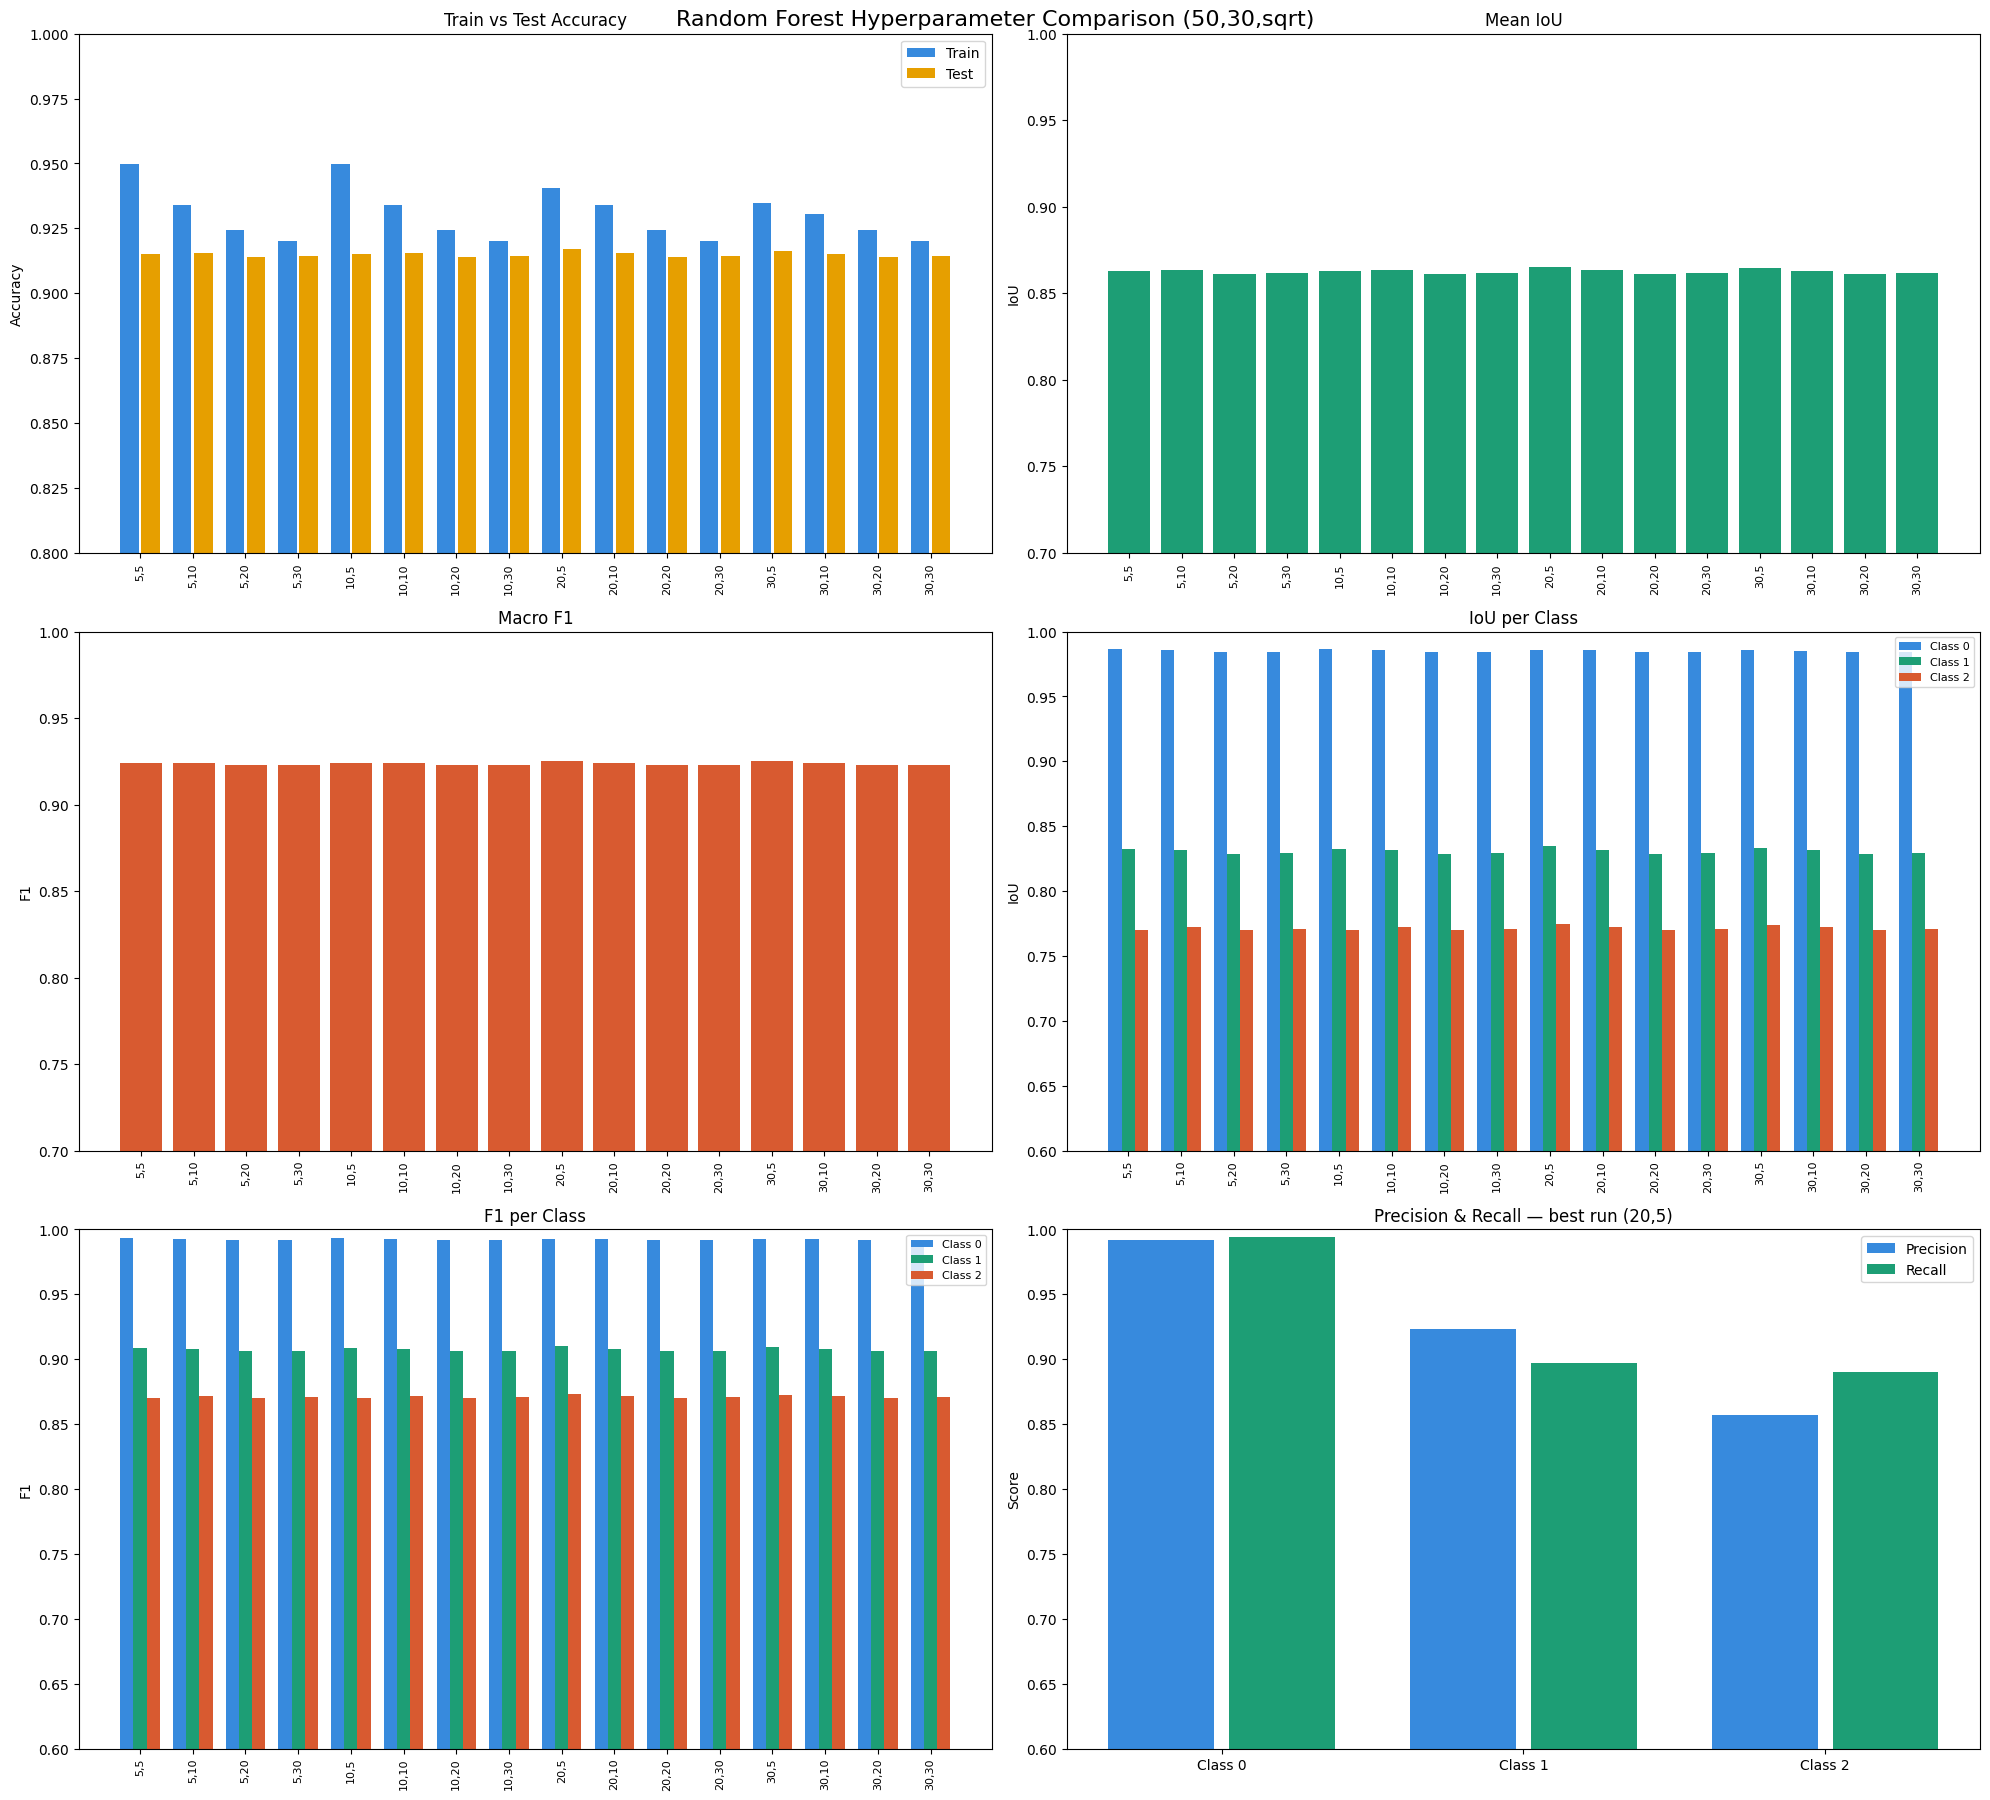


Best run: 20,5 -> test_acc=0.917


In [15]:
# ── Plots ─────────────────────────────────────────────────────────────
n_runs  = len(results)
labels  = [r["label"] for r in results]
x       = np.arange(n_runs)


fig = plt.figure(figsize=(20, 24))
fig.suptitle(f"Random Forest Hyperparameter Comparison ({best1['label'].replace(chr(10), ', ')})", fontsize=16, y=0.98)
plt.subplots_adjust(bottom=-0.3, right=0.8, top=0.9)
# ── 1. Train vs test accuracy ─────────────────────────────────────────
ax1 = fig.add_subplot(4, 2, 1)
ax1.bar(x - 0.2, [r["train_acc"] for r in results], 0.35, label="Train", color="#378ADD")
ax1.bar(x + 0.2, [r["test_acc"]  for r in results], 0.35, label="Test",  color="#E69F00")
ax1.set_xticks(x); ax1.set_xticklabels(labels, fontsize=8)
ax1.set_ylim(0.8, 1.0); ax1.set_title("Train vs Test Accuracy")
ax1.legend(); ax1.set_ylabel("Accuracy")
ax1.set_xticks(x, labels, rotation='vertical')

# ── 2. Mean IoU ───────────────────────────────────────────────────────
ax2 = fig.add_subplot(4, 2, 2)
ax2.bar(x, [r["mean_iou"] for r in results], color="#1D9E75")
ax2.set_xticks(x); ax2.set_xticklabels(labels, fontsize=8)
ax2.set_ylim(0.7, 1.0); ax2.set_title("Mean IoU")
ax2.set_ylabel("IoU")
ax2.set_xticks(x, labels, rotation='vertical')

# ── 3. Macro F1 ───────────────────────────────────────────────────────
ax3 = fig.add_subplot(4, 2, 3)
ax3.bar(x, [r["macro_f1"] for r in results], color="#D85A30")
ax3.set_xticks(x); ax3.set_xticklabels(labels, fontsize=8)
ax3.set_ylim(0.7, 1.0); ax3.set_title("Macro F1")
ax3.set_ylabel("F1")
ax3.set_xticks(x, labels, rotation='vertical')

# ── 4. IoU per class ─────────────────────────────────────────────────
ax4 = fig.add_subplot(4, 2, 4)
colors = ["#378ADD", "#1D9E75", "#D85A30"]
width  = 0.25
for i, cls in enumerate(class_names):
    ax4.bar(x + (i-1)*width, [r["iou"][i] for r in results], width,
            label=cls, color=colors[i])
ax4.set_xticks(x); ax4.set_xticklabels(labels, fontsize=8)
ax4.set_ylim(0.6, 1.0); ax4.set_title("IoU per Class")
ax4.legend(fontsize=8); ax4.set_ylabel("IoU")
ax4.set_xticks(x, labels, rotation='vertical')

# ── 5. F1 per class ──────────────────────────────────────────────────
ax5 = fig.add_subplot(4, 2, 5)
for i, cls in enumerate(class_names):
    ax5.bar(x + (i-1)*width, [r["f1"][i] for r in results], width,
            label=cls, color=colors[i])
ax5.set_xticks(x); ax5.set_xticklabels(labels, fontsize=8)
ax5.set_ylim(0.6, 1.0); ax5.set_title("F1 per Class")
ax5.legend(fontsize=8); ax5.set_ylabel("F1")
ax5.set_xticks(x, labels, rotation='vertical')

# ── 6. Precision & Recall per class (best run only) ──────────────────
best_idx = np.argmax([r["test_acc"] for r in results])
best     = results[best_idx]
x3       = np.arange(3)
ax6      = fig.add_subplot(4, 2, 6)
ax6.bar(x3 - 0.2, best["precision"], 0.35, label="Precision", color="#378ADD")
ax6.bar(x3 + 0.2, best["recall"],    0.35, label="Recall",    color="#1D9E75")
ax6.set_xticks(x3); ax6.set_xticklabels(class_names)
ax6.set_ylim(0.6, 1.0); ax6.set_title(f"Precision & Recall — best run ({best['label'].replace(chr(10), ', ')})")
ax6.legend(); ax6.set_ylabel("Score")


plt.tight_layout()
plt.savefig("rf_comparison.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"\nBest run: {results[best_idx]['label'].replace(chr(10), ', ')} -> test_acc={results[best_idx]['test_acc']:.3f}")

In [16]:
label = best['label']  # '200,30,sqrt'
parts = label.split(',')
minSample = int(parts[0])   # 200
minSampleLeaf    = int(parts[1])   # 30

## Train the RANDOM FOREST

In [17]:
print("The following hyperparameters are used:")
print(f"n_est={n_est}, depth={max_depth}, maxFeature={maxF}, minSamplesSplit={minSample}, minSampleLeaf={minSampleLeaf}")

The following hyperparameters are used:
n_est=50, depth=30, maxFeature=sqrt, minSamplesSplit=20, minSampleLeaf=5


In [18]:
# Define architecture of Random Forest
rf = RandomForestClassifier(
    # Model complexity
    n_estimators=n_est,           # More trees → more stable
    max_depth=max_depth,               # Deeper trees → capture complex patterns
    min_samples_split=minSample,       # Allow more splits
    min_samples_leaf=minSampleLeaf,         # Prevent overfitting to noise
    max_features=maxF,        # Reduces correlation between trees
    
    # Class imbalance handling
    class_weight='balanced',    # AUTO-BALANCE classes
    
    # Performance
    n_jobs=-1,                  # Use all CPU cores
    random_state=42,            # Reproducibility
    verbose=1,                  # Show progress
    
    # Optional: stricter splits for better quality
    # min_impurity_decrease=0.0001,  # Only split if improves purity
)

rf_pca = RandomForestClassifier(
    # Model complexity
    n_estimators=n_est,           # More trees → more stable
    max_depth=max_depth,               # Deeper trees → capture complex patterns
    min_samples_split=minSample,       # Allow more splits
    min_samples_leaf=minSampleLeaf,         # Prevent overfitting to noise
    max_features=maxF,        # Reduces correlation between trees
    
    # Class imbalance handling
    class_weight='balanced',    # AUTO-BALANCE classes
    
    # Performance
    n_jobs=-1,                  # Use all CPU cores
    random_state=42,            # Reproducibility
    verbose=1,                  # Show progress
    
    # Optional: stricter splits for better quality
    # min_impurity_decrease=0.0001,  # Only split if improves purity
)

In [19]:
# Train Random Forest
rf.fit(X_train, y_train)
print(f"RF train accuracy: {rf.score(X_train, y_train):.3f}")
print(f"RF test accuracy: {rf.score(X_test, y_test):.3f}")

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.


[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.4s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    0.8s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


RF train accuracy: 0.940
RF test accuracy: 0.917


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


Classification Report:
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6741
           1       0.92      0.90      0.91     13764
           2       0.86      0.89      0.87      9495

    accuracy                           0.92     30000
   macro avg       0.92      0.93      0.93     30000
weighted avg       0.92      0.92      0.92     30000


Confusion Matrix:
[[ 6700    18    23]
 [   22 12352  1390]
 [   31  1010  8454]]


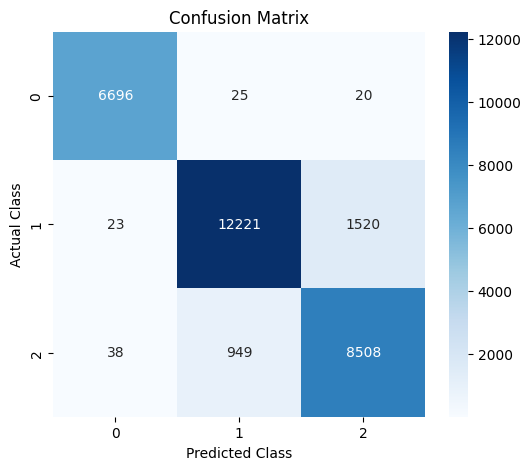

In [20]:
# Predictions
y_pred = rf.predict(X_test)

# Metrics
print("Classification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2],
            yticklabels=[0,1,2])

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()


## Feature Importance

Feature Importance Ranking:
 1. Val         : 0.1784
 2. B           : 0.1232
 3. R/B         : 0.1155
 4. G           : 0.1111
 5. G/B         : 0.0881
 6. R           : 0.0849
 7. Smooth      : 0.0674
 8. Hue         : 0.0652
 9. Norm_R-B    : 0.0452
10. Mean        : 0.0323
11. Var         : 0.0301
12. Std         : 0.0247
13. Sat         : 0.0135
14. Sobel_X     : 0.0079
15. Sobel_Y     : 0.0077
16. Laplacian   : 0.0047


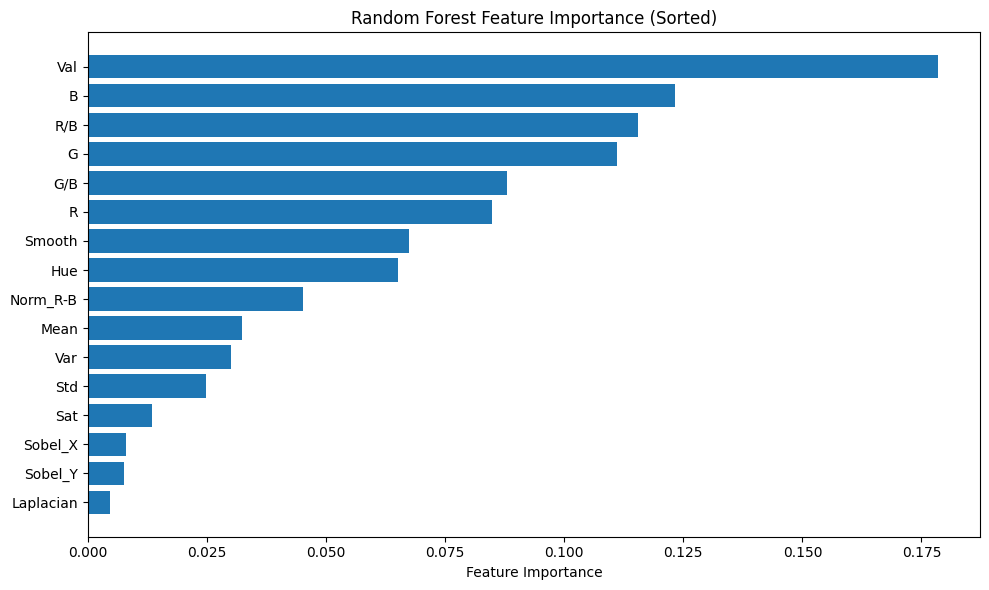

In [21]:
# Feature importance
feature_names = ['R', 'G', 'B', 'R/B', 'G/B', 'Norm_R-B', 
                 'Hue', 'Sat', 'Val', 'Smooth', 'Laplacian', 
                 'Sobel_X', 'Sobel_Y', 'Mean', 'Var', 'Std']
importances = rf.feature_importances_

# Sort by importance (descending)
indices = np.argsort(importances)[::-1]  # [::-1] reverses to descending order
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# Print sorted features
print("Feature Importance Ranking:")
print("="*40)
for i, (feat, imp) in enumerate(zip(sorted_features, sorted_importances)):
    print(f"{i+1:2d}. {feat:12s}: {imp:.4f}")

# Plot sorted
plt.figure(figsize=(10, 6))
plt.barh(sorted_features, sorted_importances)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance (Sorted)')
plt.gca().invert_yaxis()  # Highest importance at top
plt.tight_layout()
plt.show()

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finis

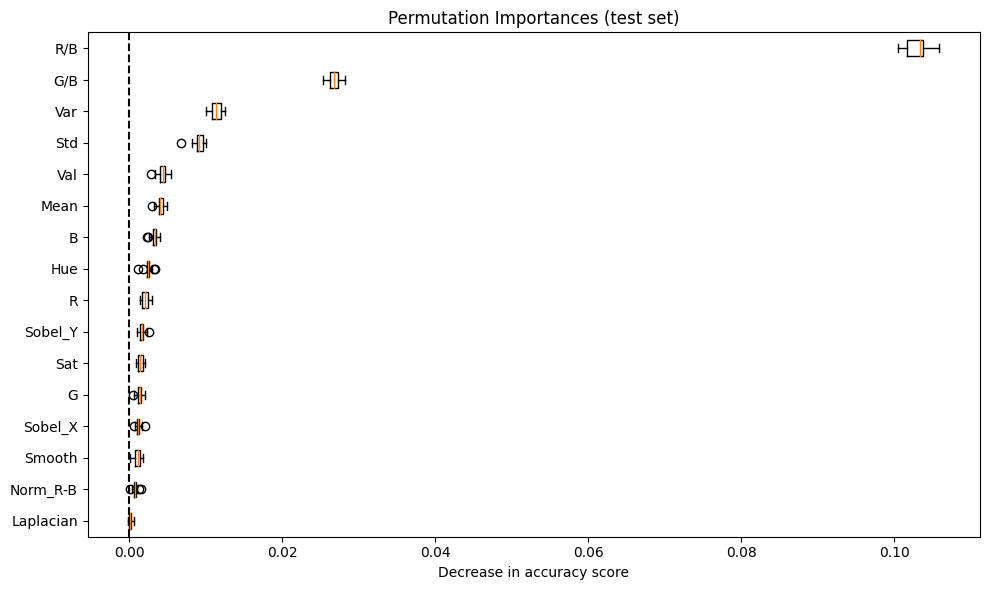

In [22]:
result = permutation_importance(
    rf, X_test, y_test, n_repeats=20, random_state=42, n_jobs=2
)

sorted_idx = result.importances_mean.argsort()

fig, ax = plt.subplots(figsize=(10, 6))
ax.boxplot(result.importances[sorted_idx].T,
           vert=False,
           labels=np.array(feature_names)[sorted_idx])
ax.set_title("Permutation Importances (test set)")
ax.axvline(x=0, color="k", linestyle="--")
ax.set_xlabel("Decrease in accuracy score")
fig.tight_layout()
plt.show()

## PCA Analysis of the Features

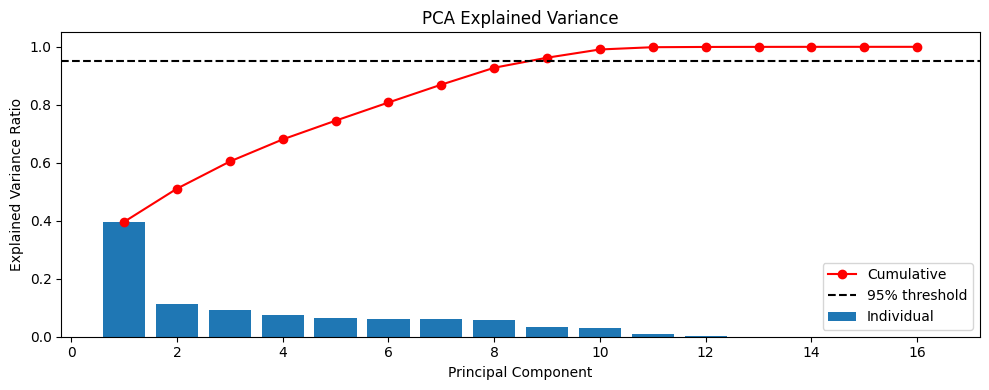

Components needed for 95% variance: 9


In [23]:
# 1. Scale first — PCA is sensitive to feature scale
scaler = StandardScaler()
X_test_scaled = scaler.fit_transform(X_test)
X_train_scaled = scaler.fit_transform(X_train)


# 2. Fit PCA
pca = PCA()
pca.fit(X_test_scaled)

# 3. Explained variance plot
explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

plt.figure(figsize=(10, 4))
plt.bar(range(1, len(explained)+1), explained, label="Individual")
plt.plot(range(1, len(explained)+1), cumulative, "o-", color="red", label="Cumulative")
plt.axhline(y=0.95, color="k", linestyle="--", label="95% threshold")
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Explained Variance")
plt.legend()
plt.tight_layout()
plt.show()

# 4. How many components for 95% variance?
n_95 = np.argmax(cumulative >= 0.95) + 1
print(f"Components needed for 95% variance: {n_95}")

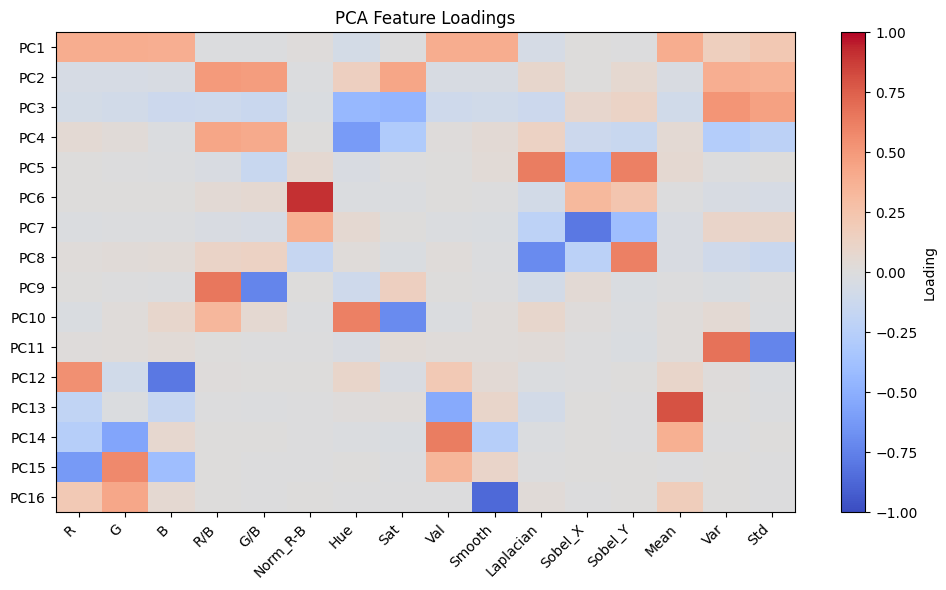

In [24]:
loadings = pca.components_  # (n_components, n_features)

plt.figure(figsize=(10, 6))
plt.imshow(loadings, cmap="coolwarm", aspect="auto", vmin=-1, vmax=1)
plt.colorbar(label="Loading")
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha="right")
plt.yticks(range(len(loadings)), [f"PC{i+1}" for i in range(len(loadings))])
plt.title("PCA Feature Loadings")
plt.tight_layout()
plt.show()

In [25]:
# See which original features dominate each PC
for i, comp in enumerate(pca.components_):
    top = np.argmax(np.abs(comp))
    print(f"PC{i+1:>2} is dominated by: {feature_names[top]:>10}  (loading: {comp[top]:.3f})")

PC 1 is dominated by:          G  (loading: 0.393)
PC 2 is dominated by:        R/B  (loading: 0.493)
PC 3 is dominated by:        Var  (loading: 0.516)
PC 4 is dominated by:        Hue  (loading: -0.610)
PC 5 is dominated by:  Laplacian  (loading: 0.629)
PC 6 is dominated by:   Norm_R-B  (loading: 0.909)
PC 7 is dominated by:    Sobel_X  (loading: -0.790)
PC 8 is dominated by:  Laplacian  (loading: -0.698)
PC 9 is dominated by:        G/B  (loading: -0.730)
PC10 is dominated by:        Sat  (loading: -0.700)
PC11 is dominated by:        Std  (loading: -0.730)
PC12 is dominated by:          B  (loading: -0.793)
PC13 is dominated by:       Mean  (loading: 0.801)
PC14 is dominated by:        Val  (loading: 0.629)
PC15 is dominated by:          R  (loading: -0.621)
PC16 is dominated by:     Smooth  (loading: -0.860)


## Train Random Forest introducing PCAs as Features

In [26]:
# Train-test split

pca_final = PCA(n_components=n_95)
X_test_pca     = pca_final.fit_transform(X_test_scaled)
X_train_pca     = pca_final.fit_transform(X_train_scaled)


print(f"\nTraining samples: {len(X_train_pca):,}")
print(f"Class distribution: {np.bincount(y_train.astype(int))}")
print(f"Test samples: {len(X_test_pca):,}")
print(f"Class distribution: {np.bincount(y_test.astype(int))}")

# Retrain and compare
rf_pca.fit(X_train_pca, y_train)
print(f"PCA RF test accuracy: {rf_pca.score(X_test_pca, y_test):.3f}")
print(f"Original RF test accuracy: {rf.score(X_test, y_test):.3f}")


Training samples: 120,000
Class distribution: [26964 55054 37982]
Test samples: 30,000
Class distribution: [ 6741 13764  9495]


[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done  18 tasks      | elapsed:    0.7s
[Parallel(n_jobs=-1)]: Done  50 out of  50 | elapsed:    1.4s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished


PCA RF test accuracy: 0.904


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished


Original RF test accuracy: 0.917



Original RF  — features: 16
  Test accuracy: 0.917


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6741
           1       0.92      0.90      0.91     13764
           2       0.86      0.89      0.87      9495

    accuracy                           0.92     30000
   macro avg       0.92      0.93      0.93     30000
weighted avg       0.92      0.92      0.92     30000


PCA RF  — features reduced to: 9
  Test accuracy: 0.904


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished


              precision    recall  f1-score   support

           0       0.99      0.99      0.99      6741
           1       0.92      0.87      0.90     13764
           2       0.83      0.89      0.86      9495

    accuracy                           0.90     30000
   macro avg       0.91      0.92      0.91     30000
weighted avg       0.91      0.90      0.90     30000



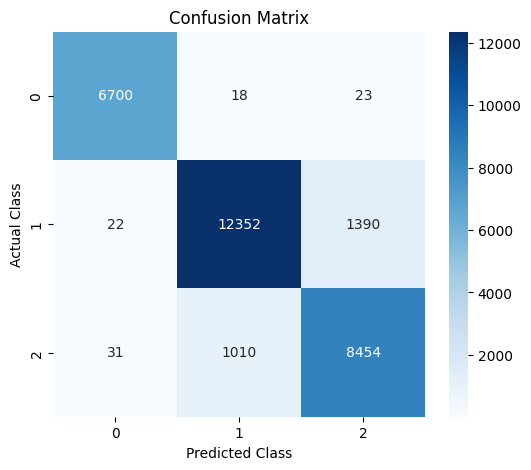

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.0s finished


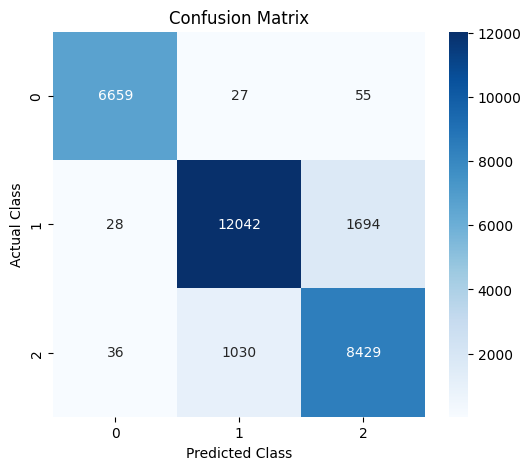

In [27]:
# ── 4. Compare ───────────────────────────────────────────────────────
print(f"\nOriginal RF  — features: {X_train.shape[1]}")
print(f"  Test accuracy: {rf.score(X_test, y_test):.3f}")
print(classification_report(y_test, rf.predict(X_test)))

print(f"\nPCA RF  — features reduced to: {n_95}")
print(f"  Test accuracy: {rf_pca.score(X_test_pca, y_test):.3f}")
print(classification_report(y_test, rf_pca.predict(X_test_pca)))


cm = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2],
            yticklabels=[0,1,2])

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()

cm = confusion_matrix(y_test, rf_pca.predict(X_test_pca))

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=[0,1,2],
            yticklabels=[0,1,2])

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix")
plt.show()


Feature Importance Ranking:
 1. PCA1        : 0.2813
 2. PCA4        : 0.2633
 3. PCA3        : 0.2076
 4. PCA2        : 0.1014
 5. PCA9        : 0.0503
 6. PCA8        : 0.0320
 7. PCA6        : 0.0216
 8. PCA5        : 0.0215
 9. PCA7        : 0.0209


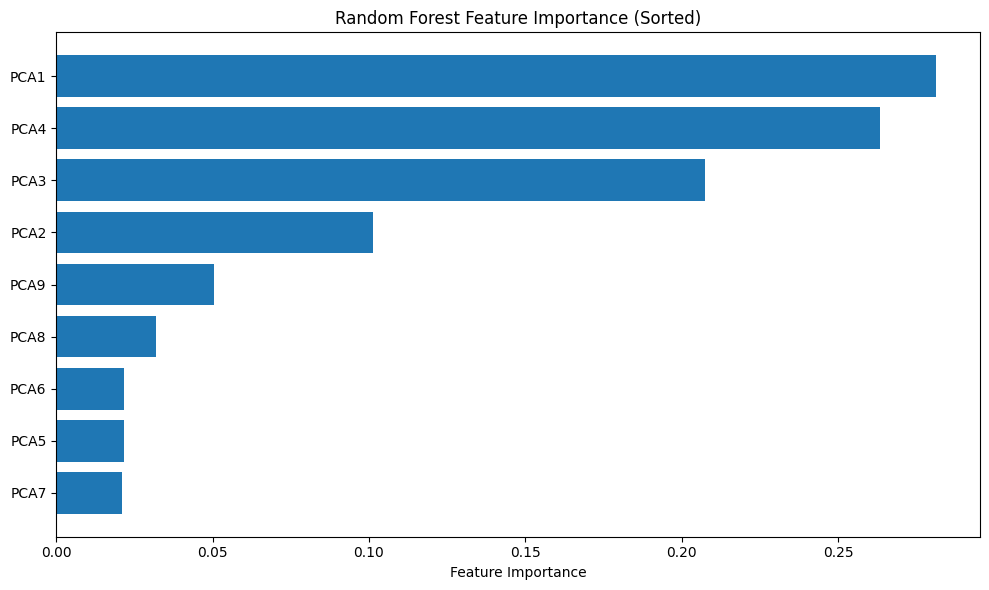

In [28]:
# Feature importance
feature_names = ['PCA1','PCA2','PCA3','PCA4','PCA5','PCA6','PCA7','PCA8','PCA9']
importances = rf_pca.feature_importances_

# Sort by importance (descending)
indices = np.argsort(importances)[::-1]  # [::-1] reverses to descending order
sorted_features = [feature_names[i] for i in indices]
sorted_importances = importances[indices]

# Print sorted features
print("Feature Importance Ranking:")
print("="*40)
for i, (feat, imp) in enumerate(zip(sorted_features, sorted_importances)):
    print(f"{i+1:2d}. {feat:12s}: {imp:.4f}")

# Plot sorted
plt.figure(figsize=(10, 6))
plt.barh(sorted_features, sorted_importances)
plt.xlabel('Feature Importance')
plt.title('Random Forest Feature Importance (Sorted)')
plt.gca().invert_yaxis()  # Highest importance at top
plt.tight_layout()
plt.show()

## Image resp. Mask Reproduction

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.2s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.


   Value      Count   Percentage
--------------------------------
      -2         12        0.0%
      -1      6,745        2.6%
       0    247,930       94.6%
       1      5,735        2.2%
       2      1,722        0.7%
   Value      Count   Percentage
--------------------------------
      -2         56        0.0%
      -1      7,979        3.0%
       0    247,157       94.3%
       1      5,127        2.0%
       2      1,825        0.7%


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished


   Value      Count   Percentage
--------------------------------
      -2        269        0.1%
      -1         44        0.0%
       0    259,825       99.1%
       1      1,977        0.8%
       2         29        0.0%
   Value      Count   Percentage
--------------------------------
      -2        192        0.1%
      -1         45        0.0%
       0    260,665       99.4%
       1      1,163        0.4%
       2         79        0.0%


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.


...

   Value      Count   Percentage
--------------------------------
      -2        110        0.0%
      -1      9,108        3.5%
       0    246,248       93.9%
       1      6,433        2.5%
       2        245        0.1%
   Value      Count   Percentage
--------------------------------
      -2        151        0.1%
      -1      9,151        3.5%
       0    246,590       94.1%
       1      6,029        2.3%
       2        223        0.1%


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.


   Value      Count   Percentage
--------------------------------
      -2         38        0.0%
      -1     18,146        6.9%
       0    239,333       91.3%
       1      4,352        1.7%
       2        275        0.1%
   Value      Count   Percentage
--------------------------------
      -2         73        0.0%
      -1     20,024        7.6%
       0    238,189       90.9%
       1      3,575        1.4%
       2        283        0.1%


[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.0s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.1s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    0.1s finished


   Value      Count   Percentage
--------------------------------
      -2         65        0.0%
      -1      8,718        3.3%
       0    223,550       85.3%
       1     26,692       10.2%
       2      3,119        1.2%
   Value      Count   Percentage
--------------------------------
      -2        126        0.0%
      -1     11,017        4.2%
       0    222,188       84.8%
       1     25,796        9.8%
       2      3,017        1.2%


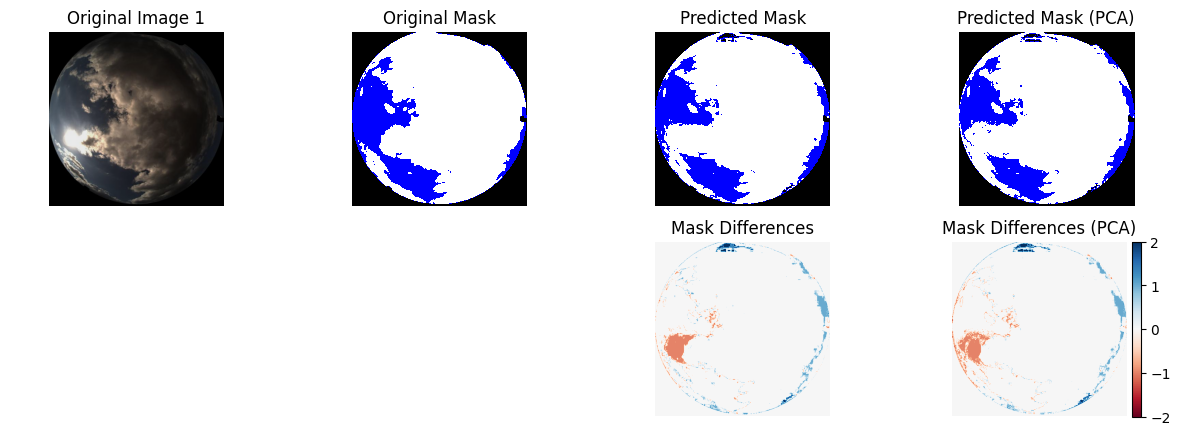

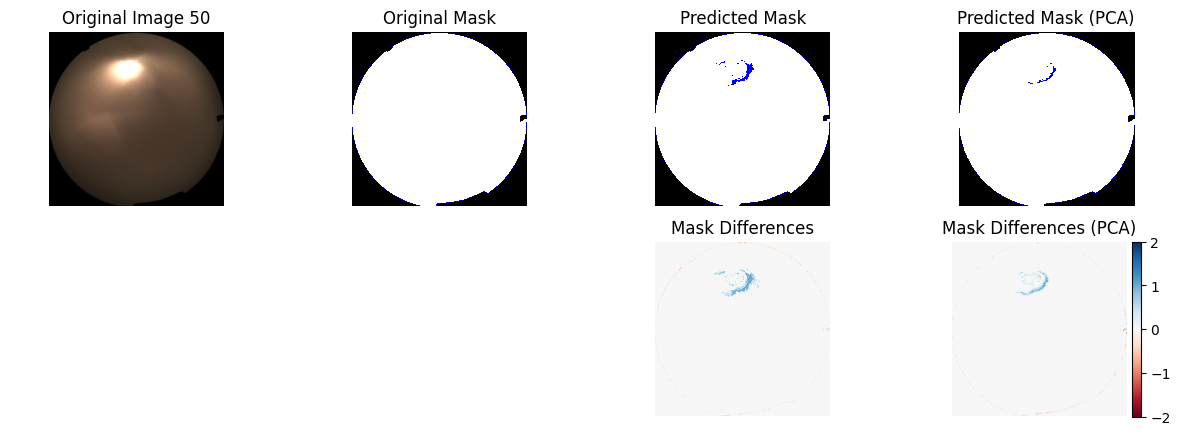

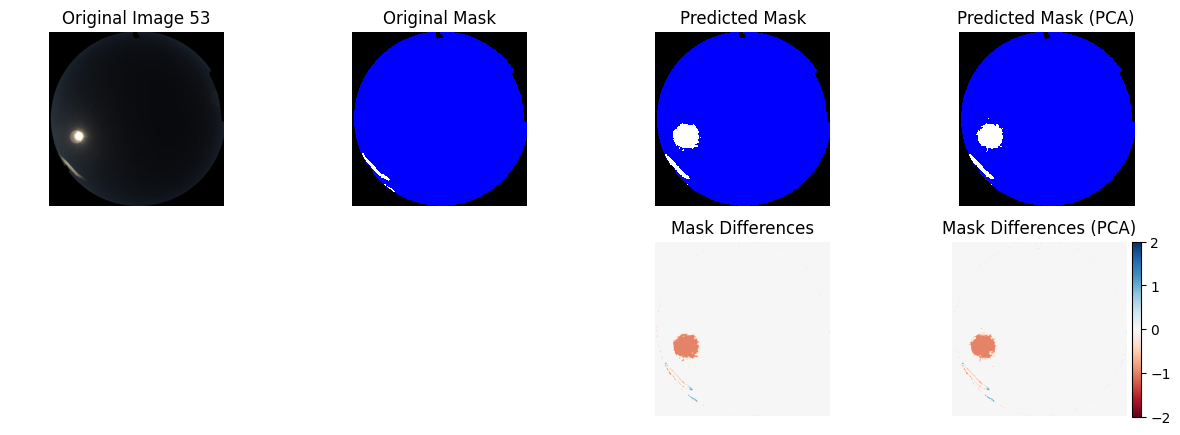

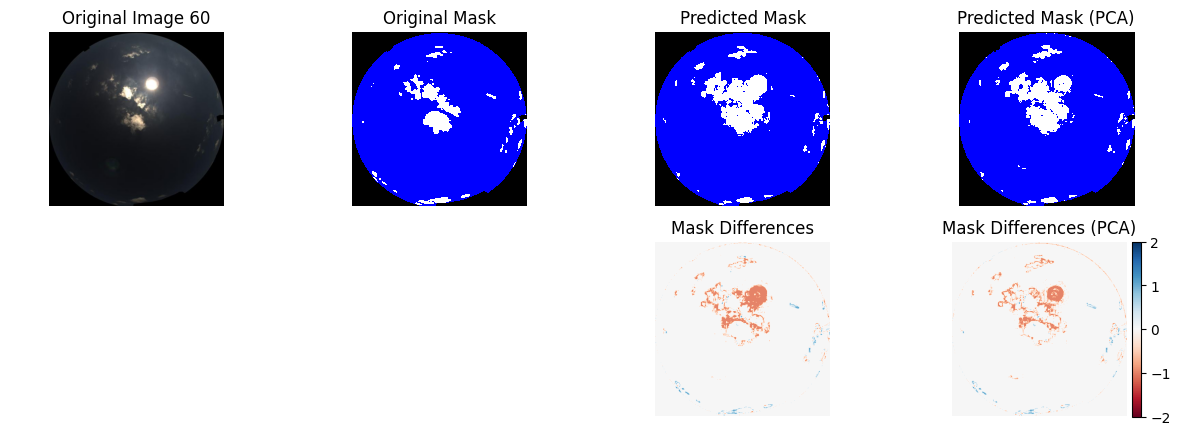

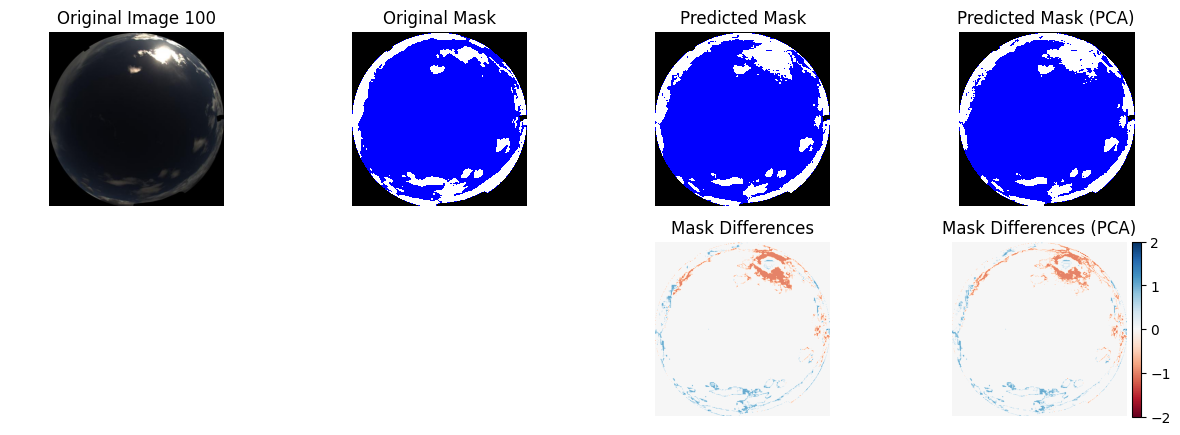

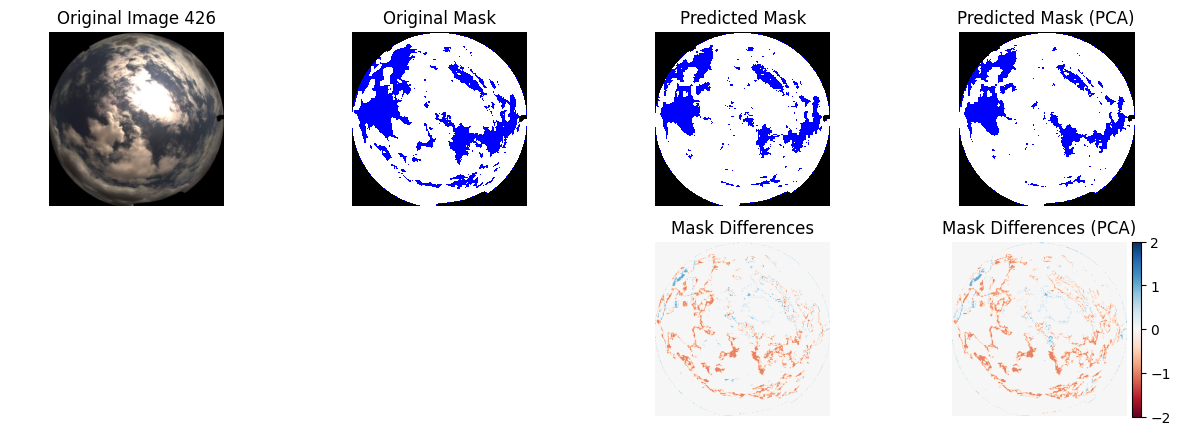

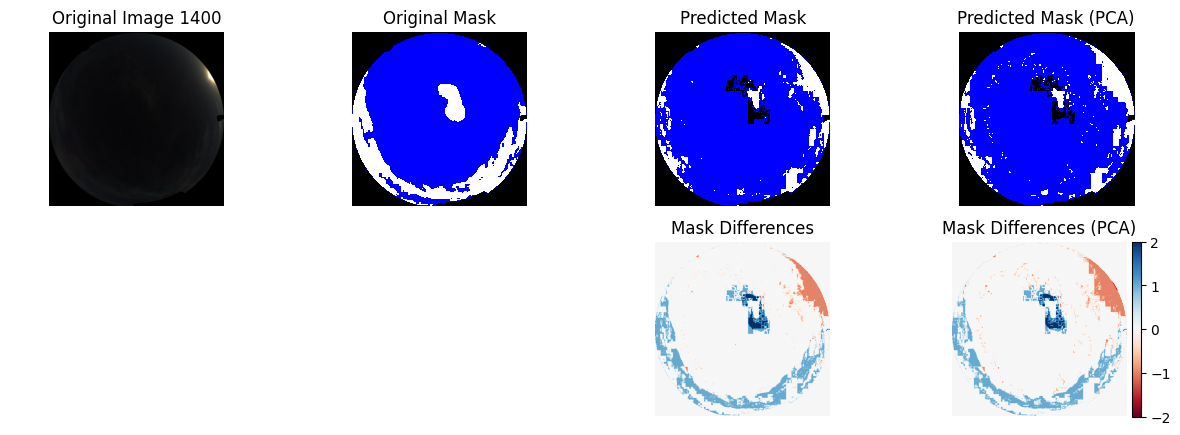

In [29]:

for idxExample in [1,50,53,60,100,426, 1400]:


    imgExample = images[idxExample:idxExample+1]

    pred_mask   = predict_image(imgExample, rf)
    pred_mask_pca = predict_image_pca(imgExample, rf_pca, scaler, pca_final)

    # Visualize results

    show_predicted_images(idxExample,imgExample,masks,pred_mask,pred_mask_pca)


## Apply Random Forest on SwissOGS Images

In [45]:
# Define image and mask files
basePath = Path(r'SwissOGS')

# Append last_dir
image_path = basePath


image_paths = sorted(Path(image_path).glob("*.jpg"))

In [53]:
# Get data


imagesOGS = []

for idx, img_path in enumerate(image_paths):
    image = Image.open(img_path).convert("RGB")
    image.load()
    imagesOGS.append(image)

# Data set
imagesOGS = [np.array(img) for img in imagesOGS]

print("Number of images: ",len(imagesOGS))

print(" - Size of a image: ",imagesOGS[0].shape)

Number of images:  6
 - Size of a image:  (2822, 3044, 3)


In [60]:
def show_predicted_imagesOGS(idxExample,imgExample,pred_mask,pred_mask_pca):

    cmap = ListedColormap(['black', 'blue', 'white'])

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    axes[0].imshow(np.array(imgExample))
    axes[0].set_title(f'Original Image {idxExample}')
    axes[0].axis('off')

    axes[1].imshow(pred_mask.squeeze(), cmap=cmap, vmin=0, vmax=2)
    axes[1].set_title(f'Predicted Mask')
    axes[1].axis('off')


    axes[2].imshow(pred_mask_pca.squeeze(), cmap=cmap, vmin=0, vmax=2)
    axes[2].set_title(f'Predicted Mask (PCA)')
    axes[2].axis('off')



<class 'numpy.ndarray'> (2822, 3044, 3)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.9s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    1.7s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.8s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    1.7s finished


<class 'numpy.ndarray'> (2822, 3044, 3)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.9s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    1.9s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    0.9s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    1.9s finished


<class 'numpy.ndarray'> (2822, 3044, 3)


...

[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.2s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    2.3s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.3s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    2.5s finished


<class 'numpy.ndarray'> (2822, 3044, 3)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.5s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    2.6s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.4s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    2.7s finished


<class 'numpy.ndarray'> (2822, 3044, 3)


[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.3s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    2.5s finished
[Parallel(n_jobs=16)]: Using backend ThreadingBackend with 16 concurrent workers.
[Parallel(n_jobs=16)]: Done  18 tasks      | elapsed:    1.3s
[Parallel(n_jobs=16)]: Done  50 out of  50 | elapsed:    2.4s finished


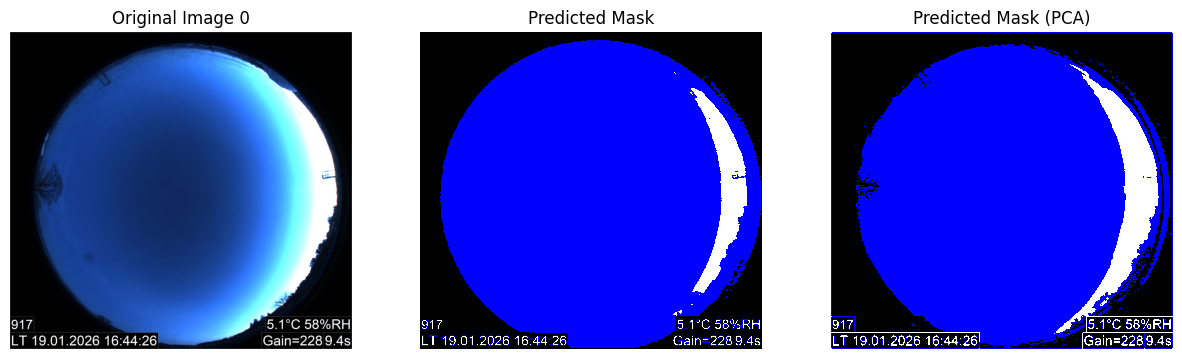

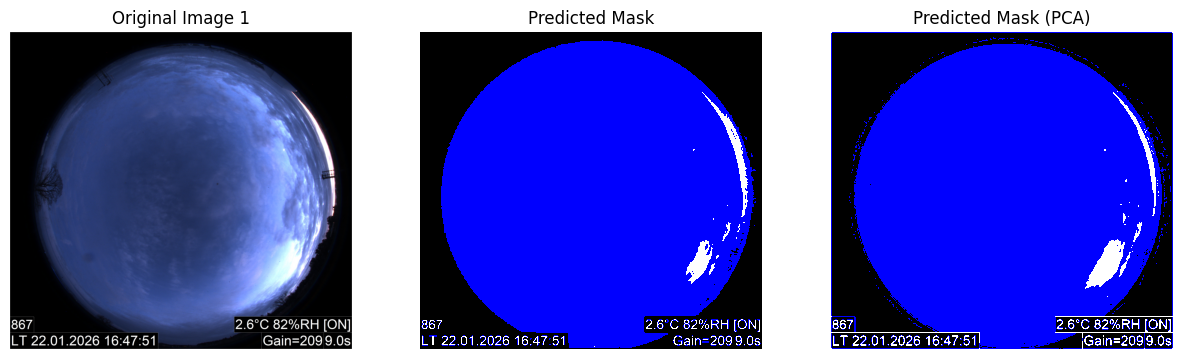

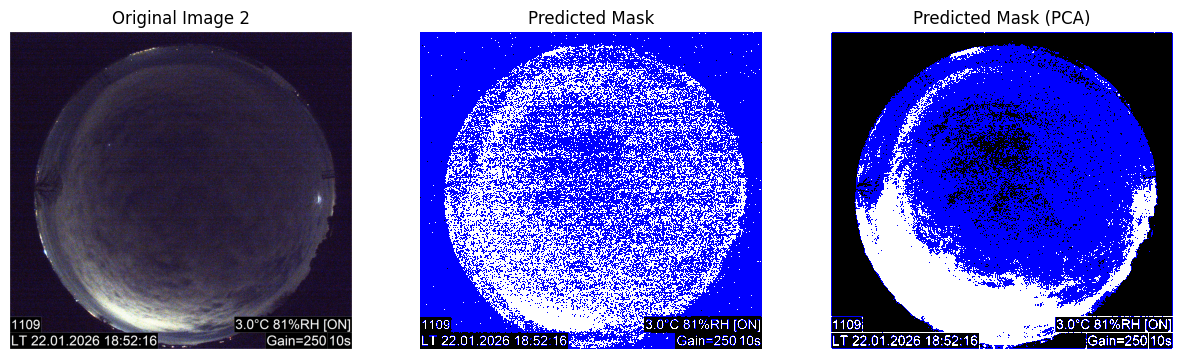

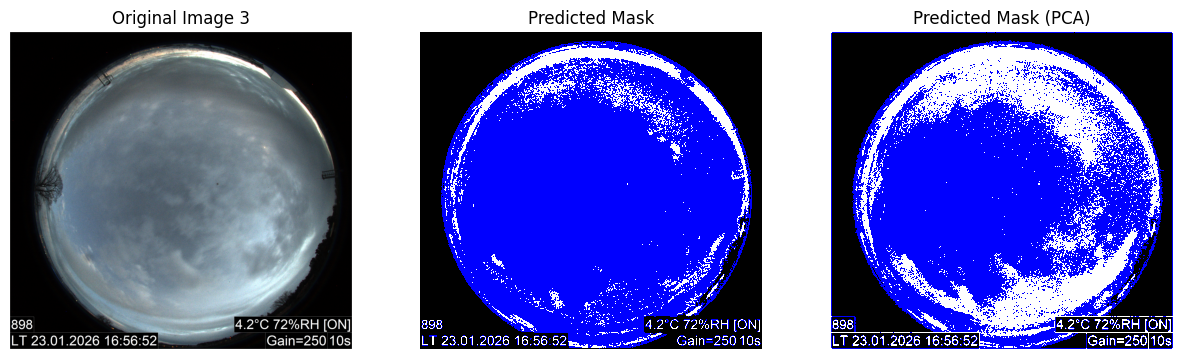

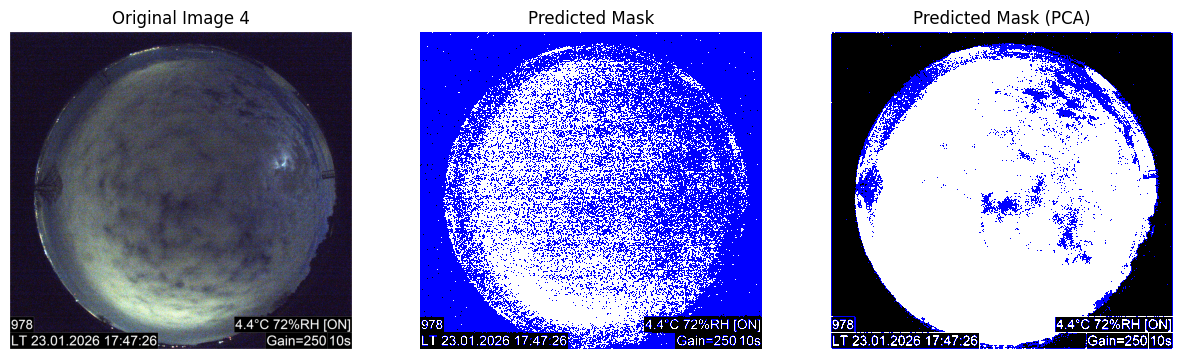

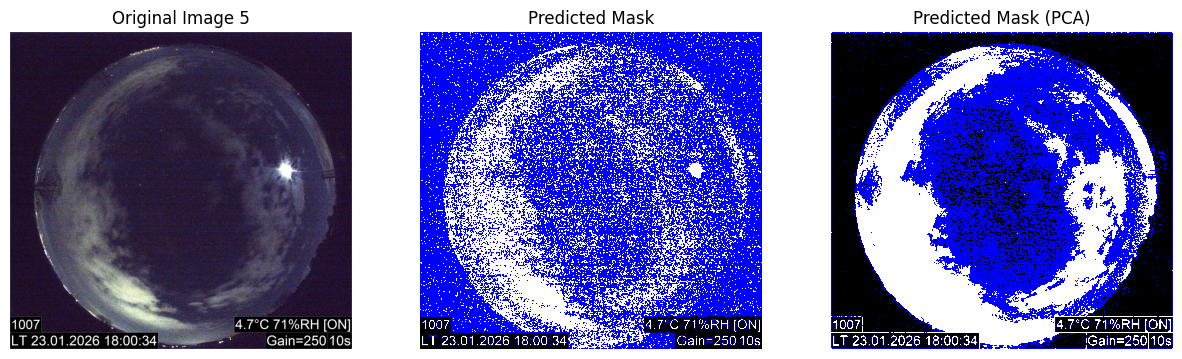

In [63]:
for idxExample in range(len(imagesOGS)):

    imgExample = imagesOGS[idxExample]
    print(type(imagesOGS[idxExample]), imagesOGS[idxExample].shape)

    pred_mask   = predict_image(imgExample, rf)
    pred_mask_pca = predict_image_pca(imgExample, rf_pca, scaler, pca_final)

    # Visualize results

    show_predicted_imagesOGS(idxExample,imgExample,pred_mask,pred_mask_pca)

## Save the Model

In [30]:
# Save trained model
joblib.dump(rf, 'cloud_detection_rf.pkl')
print("Model saved!")

# Load model later with:
# rf_loaded = joblib.load('cloud_detection_rf.pkl')

Model saved!
